# ML4SCI HEPSIM GSoC 2026 — Quark vs Gluon Jet Analysis

**Name:** Vennela Varshini Anasoori
**GitHub:** [https://github.com/vennelavarshini18](https://github.com/vennelavarshini18)
**Email:** [vennelavarshini07@gmail.com](mailto:vennelavarshini07@gmail.com)

---

## Summary

In this notebook, I work with the **Pythia 8 Quark vs Gluon Jets dataset** to understand the differences between quark jets and gluon jets and build a simple classifier to distinguish them.

I load about **100k jets** and compute some important jet features such as:

* Jet mass
* Jet width
* pT dispersion

I also apply a **Lorentz boost** to convert all jet particles into the **jet rest frame**. I implemented this in a vectorized way so it runs efficiently.

Using these features, I train a **Gradient Boosting classifier**. The model achieves an **AUC of around 0.80**. Among all features, **constituent multiplicity** turns out to be the most useful for separating quark and gluon jets.

I also compare results using **lab-frame features vs rest-frame features**. For these simple jet-level features, the boost does not improve performance much. However, it could still be useful for more complex models that use **constituent-level information**, such as deep learning approaches.

---

## Key Observations

| Feature      | Quark Jets | Gluon Jets | What I Noticed                             |
| ------------ | ---------- | ---------- | ----------------------------------------- |
| Multiplicity | Lower      | Higher     | Gluons produce more radiation             |
| Jet Mass     | Lower      | Higher     | More radiation makes jets heavier         |
| Jet Width    | Narrower   | Wider      | Gluon jets spread out more                |
| pTD          | Higher     | Lower      | Quark jets have energy in fewer particles |

---

## Model Result

I trained a **Gradient Boosting classifier**.

* **AUC ≈ 0.80**
* **Most important feature:** Multiplicity

This shows that the number of particles inside a jet already provides strong information for distinguishing quark jets from gluon jets.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, classification_report
import urllib.request
import os
import warnings
# ignore warnings to keep output clean
warnings.filterwarnings("ignore")

# basic plot settings
plt.rcParams["figure.figsize"] = (12,5)
plt.rcParams["font.size"] = 12

print("Imports loaded")

Imports loaded


In [2]:
url = "https://zenodo.org/records/3164691/files/QG_jets.npz?download=1"
file_name = "QG_jets.npz"
# download dataset if only not already present
if not os.path.exists(file_name):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, file_name)
    print("Done downloading")
else:
    print("Dataset already exists")
    
# load the dataset
data = np.load(file_name, allow_pickle=True)
print("Keys in dataset:", list(data.keys()))

Done downloading
Keys in dataset: ['X', 'y']


In [3]:
# each jet has many particles (pT, eta, phi, pdgid)
# padded particles have pT = 0

X = data['X']   # jet constituents
y = data['y']   # labels (0 = gluon, 1 = quark)
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nQuark jets:", int(np.sum(y == 1)))
print("Gluon jets:", int(np.sum(y == 0)))

print("\nMax constituents per jet:", X.shape[1])
print("Features per particle: [pT, eta, phi, pdgid]")

X shape: (100000, 139, 4)
y shape: (100000,)

Quark jets: 50000
Gluon jets: 50000

Max constituents per jet: 139
Features per particle: [pT, eta, phi, pdgid]


In [5]:
# (a-i) count total real constituents in quark and gluon jets
# real particles have pT > 0 (padded ones have pT = 0)
q_mask = (y == 1)
g_mask = (y == 0)

X_q = X[q_mask]   # quark jets
X_g = X[g_mask]   # gluon jets
n_q = int(np.sum(X_q[:, :, 0] > 0))
n_g = int(np.sum(X_g[:, :, 0] > 0))

print("=" * 45)
print("Total real constituents")
print("=" * 45)
print(f"Quark jets : {n_q:,}")
print(f"Gluon jets : {n_g:,}")
print(f"Ratio g/q  : {n_g/n_q:.4f}")
print("=" * 45)

print("\nI notice that gluon jets have roughly ~9/4 times more particles on average.")
print("This comes from the Casimir factor ratio: C_A/C_F = 3/(4/3) = 9/4.")

Total real constituents
Quark jets : 1,669,999
Gluon jets : 2,660,906
Ratio g/q  : 1.5934

I notice that gluon jets have roughly ~9/4 times more particles on average.
This comes from the Casimir factor ratio: C_A/C_F = 3/(4/3) = 9/4.


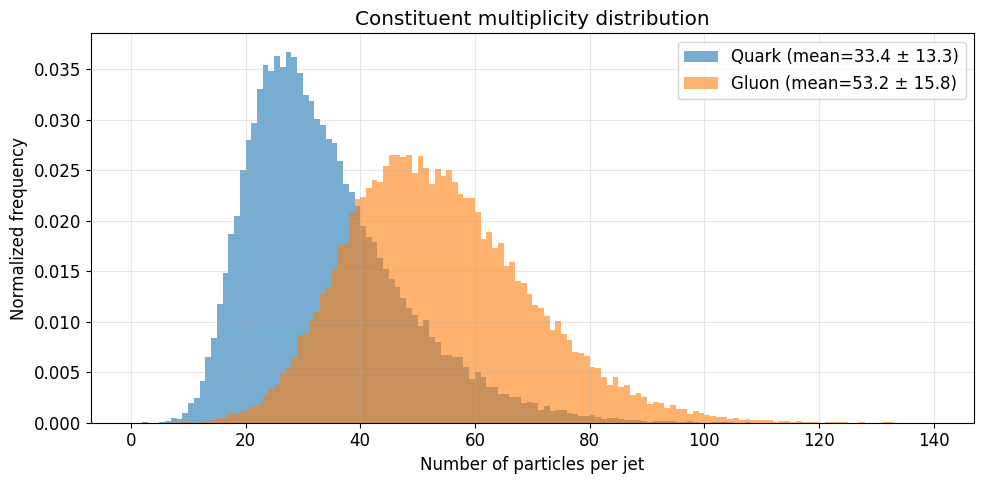

Quark mean multiplicity : 33.40 ± 13.34
Gluon mean multiplicity : 53.22 ± 15.76

I can see that gluon jets usually have more particles than quark jets.
This happens because gluons radiate more due to their larger color charge (C_A = 3 vs C_F = 4/3).


In [6]:
# (a-ii) multiplicity distribution of jet constituents

def multiplicity(jets):
    # count real particles in each jet (pT > 0)
    return np.sum(jets[:, :, 0] > 0, axis=1)

mult_q = multiplicity(X_q)
mult_g = multiplicity(X_g)

bins = np.arange(0, max(mult_q.max(), mult_g.max()) + 2)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(mult_q, bins=bins, alpha=0.6, density=True,
        label=f"Quark (mean={mult_q.mean():.1f} ± {mult_q.std():.1f})")

ax.hist(mult_g, bins=bins, alpha=0.6, density=True,
        label=f"Gluon (mean={mult_g.mean():.1f} ± {mult_g.std():.1f})")

ax.set_xlabel("Number of particles per jet")
ax.set_ylabel("Normalized frequency")
ax.set_title("Constituent multiplicity distribution")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Quark mean multiplicity : {mult_q.mean():.2f} ± {mult_q.std():.2f}")
print(f"Gluon mean multiplicity : {mult_g.mean():.2f} ± {mult_g.std():.2f}")

print("\nI can see that gluon jets usually have more particles than quark jets.")
print("This happens because gluons radiate more due to their larger color charge (C_A = 3 vs C_F = 4/3).")

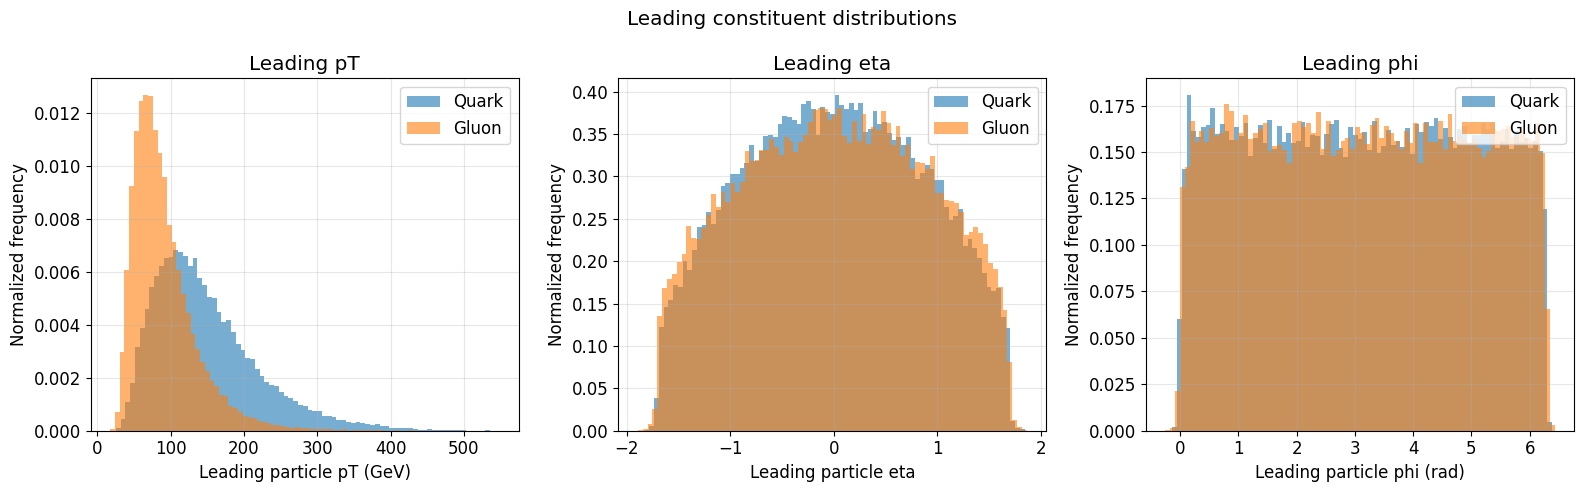

Leading pT — Quark: 148.64 GeV | Gluon: 90.77 GeV
Leading eta — Quark: -0.0004 | Gluon: 0.0058

From this I can see that quark jets usually have a harder leading particle,
meaning more energy is concentrated in the leading constituent.


In [7]:
# (a-iii) distribution of the leading (highest pT) particle in each jet
def get_leading(jets):
    # get the particle with highest pT in every jet
    idx = np.argmax(jets[:, :, 0], axis=1)
    return jets[np.arange(len(jets)), idx]   # returns (pT, eta, phi, pdgid)

lead_q = get_leading(X_q)
lead_g = get_leading(X_g)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# pT distribution
axes[0].hist(lead_q[:, 0], bins=80, alpha=0.6, density=True, label="Quark")
axes[0].hist(lead_g[:, 0], bins=80, alpha=0.6, density=True, label="Gluon")
axes[0].set_xlabel("Leading particle pT (GeV)")
axes[0].set_ylabel("Normalized frequency")
axes[0].set_title("Leading pT")
axes[0].legend()
axes[0].grid(alpha=0.3)

# eta distribution
axes[1].hist(lead_q[:, 1], bins=80, alpha=0.6, density=True, label="Quark")
axes[1].hist(lead_g[:, 1], bins=80, alpha=0.6, density=True, label="Gluon")
axes[1].set_xlabel("Leading particle eta")
axes[1].set_ylabel("Normalized frequency")
axes[1].set_title("Leading eta")
axes[1].legend()
axes[1].grid(alpha=0.3)

# phi distribution
axes[2].hist(lead_q[:, 2], bins=80, alpha=0.6, density=True, label="Quark")
axes[2].hist(lead_g[:, 2], bins=80, alpha=0.6, density=True, label="Gluon")
axes[2].set_xlabel("Leading particle phi (rad)")
axes[2].set_ylabel("Normalized frequency")
axes[2].set_title("Leading phi")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle("Leading constituent distributions")
plt.tight_layout()
plt.show()

print(f"Leading pT — Quark: {lead_q[:,0].mean():.2f} GeV | Gluon: {lead_g[:,0].mean():.2f} GeV")
print(f"Leading eta — Quark: {lead_q[:,1].mean():.4f} | Gluon: {lead_g[:,1].mean():.4f}")

print("\nFrom this I can see that quark jets usually have a harder leading particle,")
print("meaning more energy is concentrated in the leading constituent.")

In [8]:
# (b) Jet observables — convert (pT, eta, phi) to 4-momentum (E, px, py, pz)
# assume particles are massless → E = |p| = pT * cosh(eta)

def to_4mom(jets):
    # convert each constituent to 4-momentum
    pT  = jets[:, :, 0]
    eta = jets[:, :, 1]
    phi = jets[:, :, 2]

    E  = pT * np.cosh(eta)
    px = pT * np.cos(phi)
    py = pT * np.sin(phi)
    pz = pT * np.sinh(eta)
    return np.stack([E, px, py, pz], axis=-1)

mom4_q = to_4mom(X_q)
mom4_g = to_4mom(X_g)

# mask for real particles (pT > 0)
mask_q = X_q[:, :, 0] > 0
mask_g = X_g[:, :, 0] > 0

print("4-momentum arrays computed")
print("mom4_q shape:", mom4_q.shape, "(n_jets, max_const, 4)")

4-momentum arrays computed
mom4_q shape: (50000, 139, 4) (n_jets, max_const, 4)


In [9]:
# sum all constituent 4-momenta to get the jet 4-momentum

def jet_4mom(mom4, mask):
    # add only real particles (pT > 0)
    return np.sum(mom4 * mask[:, :, None], axis=1)

pJ_q = jet_4mom(mom4_q, mask_q)
pJ_g = jet_4mom(mom4_g, mask_g)

print("Jet 4-momentum shape:", pJ_q.shape)
print("Example quark jet (E, px, py, pz):", pJ_q[0].round(3), "GeV")

Jet 4-momentum shape: (50000, 4)
Example quark jet (E, px, py, pz): [ 501.215   19.008 -500.369  -15.042] GeV


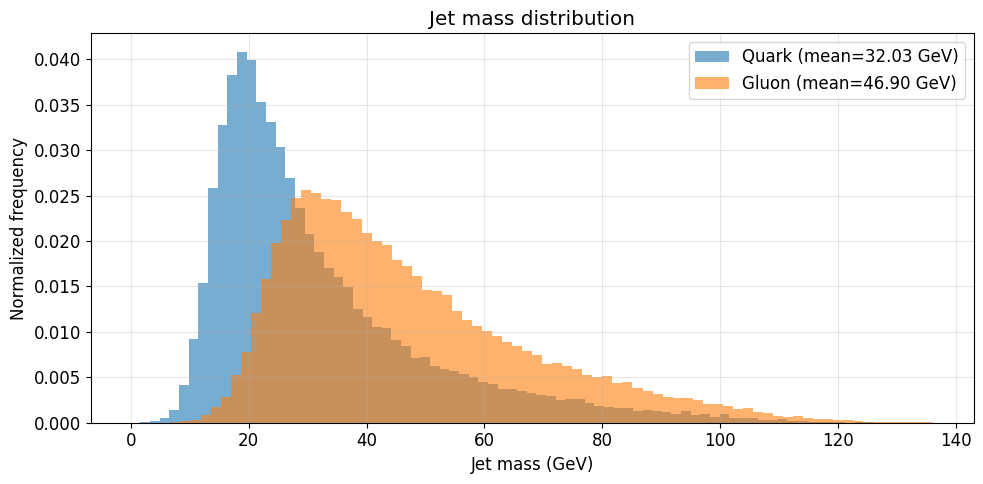

Quark jet mass : 32.032 ± 18.721 GeV
Gluon jet mass : 46.899 ± 20.751 GeV

From this I see that gluon jets tend to have slightly larger mass.
This happens because gluons radiate more particles inside the jet.


In [10]:
# (b-i) Jet invariant mass
# m^2 = E^2 - px^2 - py^2 - pz^2

def jet_mass(pJ):
    m2 = pJ[:,0]**2 - pJ[:,1]**2 - pJ[:,2]**2 - pJ[:,3]**2
    return np.sqrt(np.maximum(m2, 0))   # avoid tiny negative values

mass_q = jet_mass(pJ_q)
mass_g = jet_mass(pJ_g)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(mass_q, bins=80, alpha=0.6, density=True,
        label=f"Quark (mean={mass_q.mean():.2f} GeV)")
ax.hist(mass_g, bins=80, alpha=0.6, density=True,
        label=f"Gluon (mean={mass_g.mean():.2f} GeV)")

ax.set_xlabel("Jet mass (GeV)")
ax.set_ylabel("Normalized frequency")
ax.set_title("Jet mass distribution")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Quark jet mass : {mass_q.mean():.3f} ± {mass_q.std():.3f} GeV")
print(f"Gluon jet mass : {mass_g.mean():.3f} ± {mass_g.std():.3f} GeV")

print("\nFrom this I see that gluon jets tend to have slightly larger mass.")
print("This happens because gluons radiate more particles inside the jet.")

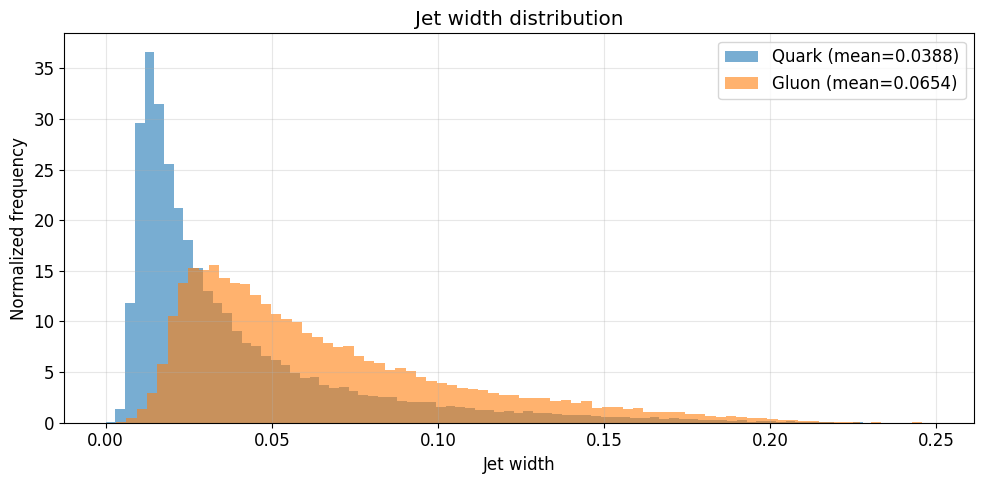

Quark jet width : 0.03880 ± 0.03515
Gluon jet width : 0.06542 ± 0.04098

From this I see that gluon jets are usually wider.
This matches the idea that gluons radiate more particles around the jet.


In [11]:
# (b-ii) Jet width
# w = sum(pT_i * dR_i) / sum(pT_i),  where dR = sqrt(deta^2 + dphi^2)

def jet_width(jets, pJ):
    pT  = jets[:, :, 0]
    eta = jets[:, :, 1]
    phi = jets[:, :, 2]

    mask = pT > 0   # only real particles

    # jet direction
    pT_J  = np.sqrt(pJ[:,1]**2 + pJ[:,2]**2)
    eta_J = np.arcsinh(pJ[:,3] / (pT_J + 1e-10))
    phi_J = np.arctan2(pJ[:,2], pJ[:,1])

    # distance from jet axis
    deta = eta - eta_J[:, None]
    dphi = (phi - phi_J[:, None] + np.pi) % (2*np.pi) - np.pi
    dR   = np.sqrt(deta**2 + dphi**2)

    num   = np.sum(pT * dR * mask, axis=1)
    denom = np.sum(pT * mask, axis=1)

    return num / (denom + 1e-10)

width_q = jet_width(X_q, pJ_q)
width_g = jet_width(X_g, pJ_g)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(width_q, bins=80, alpha=0.6, density=True,
        label=f"Quark (mean={width_q.mean():.4f})")
ax.hist(width_g, bins=80, alpha=0.6, density=True,
        label=f"Gluon (mean={width_g.mean():.4f})")

ax.set_xlabel("Jet width")
ax.set_ylabel("Normalized frequency")
ax.set_title("Jet width distribution")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Quark jet width : {width_q.mean():.5f} ± {width_q.std():.5f}")
print(f"Gluon jet width : {width_g.mean():.5f} ± {width_g.std():.5f}")

print("\nFrom this I see that gluon jets are usually wider.")
print("This matches the idea that gluons radiate more particles around the jet.")

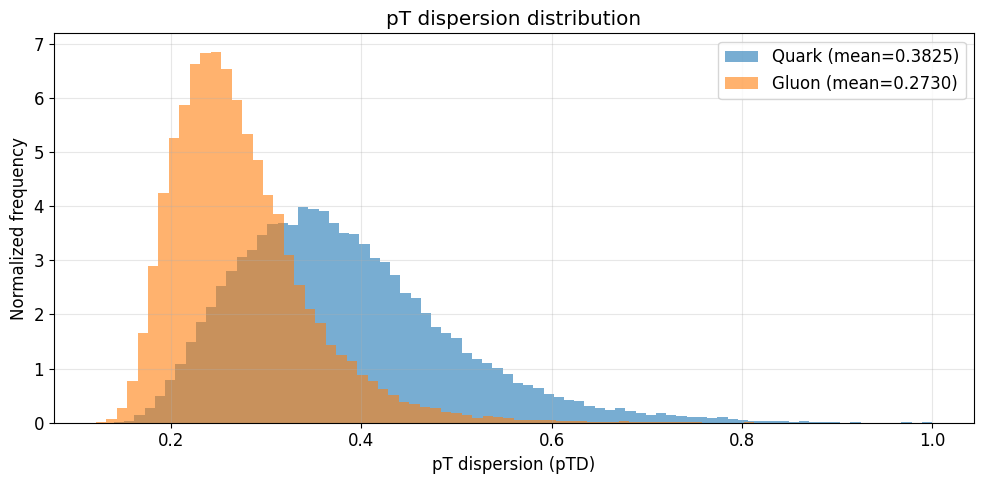

Quark pTD : 0.38250 ± 0.11344
Gluon pTD : 0.27303 ± 0.07292

From this I see that quark jets usually have higher pTD.
This means their energy is concentrated in fewer, harder particles.


In [12]:
# (b-iii) pT dispersion
# pTD = sqrt(sum(pT_i^2)) / sum(pT_i)

def pT_dispersion(jets):
    pT = jets[:, :, 0]
    mask = pT > 0   # only real particles

    num = np.sqrt(np.sum(pT**2 * mask, axis=1))
    den = np.sum(pT * mask, axis=1)

    return num / (den + 1e-10)

ptd_q = pT_dispersion(X_q)
ptd_g = pT_dispersion(X_g)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(ptd_q, bins=80, alpha=0.6, density=True,
        label=f"Quark (mean={ptd_q.mean():.4f})")
ax.hist(ptd_g, bins=80, alpha=0.6, density=True,
        label=f"Gluon (mean={ptd_g.mean():.4f})")

ax.set_xlabel("pT dispersion (pTD)")
ax.set_ylabel("Normalized frequency")
ax.set_title("pT dispersion distribution")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Quark pTD : {ptd_q.mean():.5f} ± {ptd_q.std():.5f}")
print(f"Gluon pTD : {ptd_g.mean():.5f} ± {ptd_g.std():.5f}")

print("\nFrom this I see that quark jets usually have higher pTD.")
print("This means their energy is concentrated in fewer, harder particles.")

## (c) Boost to Jet Center-of-Mass Frame

To study the jet structure more clearly, I boost all jet constituents to the **jet rest frame** (center-of-mass frame).
In this frame, the **total 3-momentum of the jet becomes 0**.

### Boost Vector

For a jet with 4-momentum

pJ = (EJ, pxJ, pyJ, pzJ)

the boost velocity is

β = (pxJ, pyJ, pzJ) / EJ

The Lorentz factor is

γ = 1 / √(1 − |β|²) = EJ / mJ

where mJ is the jet invariant mass.

### Applying the Boost

For each constituent with 4-momentum

p = (E, px, py, pz)

the boosted values are computed using the **Lorentz boost equations**:

E' = γ(E − β · p)

p' = p + β[(γ − 1)(β · p)/|β|² − γE]

In this notebook, I apply this boost to all jet constituents using the **Lorentz boost matrix**, so that each jet is analyzed in its **own rest frame**.
After the boost, the total momentum of the jet should be approximately zero (small differences can appear due to floating point precision).


In [13]:
def lorentz_boost_to_rest(mom4_jet, pJ):
    # boost all jet constituents to the jet rest frame

    # jet energy and momentum
    E_J = pJ[:, 0]
    p_J = pJ[:, 1:]

    # jet mass
    mJ_sq = E_J**2 - np.sum(p_J**2, axis=1)
    mJ = np.sqrt(np.maximum(mJ_sq, 1e-10))

    # boost vector β = p_J / E_J
    beta = p_J / E_J[:, None]
    beta_sq = np.sum(beta**2, axis=1)
    beta_mag = np.sqrt(np.maximum(beta_sq, 1e-20))
    gamma = E_J / mJ

    # constituent energy and momentum
    E_c = mom4_jet[:, :, 0]
    p_c = mom4_jet[:, :, 1:]

    beta_dot_p = np.sum(beta[:, None, :] * p_c, axis=-1)

    g = gamma[:, None]
    bm = beta_mag[:, None]

    # boosted energy
    E_boost = g * (E_c - beta_dot_p)

    # unit direction of β
    beta_hat = beta / (beta_mag[:, None] + 1e-20)
    beta_hat_exp = beta_hat[:, None, :]

    # momentum parallel to β
    p_par_mag = np.sum(p_c * beta_hat_exp, axis=-1)
    p_par_boost_mag = g * (p_par_mag - bm * E_c)
    p_par_boost = p_par_boost_mag[:, :, None] * beta_hat_exp

    # perpendicular momentum (unchanged)
    p_perp = p_c - p_par_mag[:, :, None] * beta_hat_exp
    p_boost = p_par_boost + p_perp

    # return boosted 4-momentum
    return np.concatenate([E_boost[:, :, None], p_boost], axis=-1)


print("Lorentz boost function defined")
print("β = p_J / E_J   and   γ = E_J / m_J")

Lorentz boost function defined
β = p_J / E_J   and   γ = E_J / m_J


In [14]:
# (c-ii) verify that total 3-momentum is ~0 after boosting to rest frame

N_verify = 1000

mom4_q_boost = lorentz_boost_to_rest(mom4_q[:N_verify], pJ_q[:N_verify])
mom4_g_boost = lorentz_boost_to_rest(mom4_g[:N_verify], pJ_g[:N_verify])

def total_3mom(boosted, mask):
    # sum px, py, pz of all constituents
    return np.sum(boosted[:, :, 1:] * mask[:, :, None], axis=1)

tp_q = total_3mom(mom4_q_boost, mask_q[:N_verify])
tp_g = total_3mom(mom4_g_boost, mask_g[:N_verify])

print("=" * 50)
print("Check total 3-momentum after boost")
print("=" * 50)

for label, tp in [("Quark", tp_q), ("Gluon", tp_g)]:
    print(f"{label} jets (N={N_verify})")
    print(f"  max |px| = {np.abs(tp[:,0]).max():.2e} GeV")
    print(f"  max |py| = {np.abs(tp[:,1]).max():.2e} GeV")
    print(f"  max |pz| = {np.abs(tp[:,2]).max():.2e} GeV")

print("=" * 50)
print("From this I see the total momentum is extremely close to 0.")
print("So the Lorentz boost to the jet rest frame is working correctly.")

Check total 3-momentum after boost
Quark jets (N=1000)
  max |px| = 2.04e-11 GeV
  max |py| = 1.50e-11 GeV
  max |pz| = 4.07e-11 GeV
Gluon jets (N=1000)
  max |px| = 8.93e-12 GeV
  max |py| = 1.65e-11 GeV
  max |pz| = 3.97e-11 GeV
From this I see the total momentum is extremely close to 0.
So the Lorentz boost to the jet rest frame is working correctly.


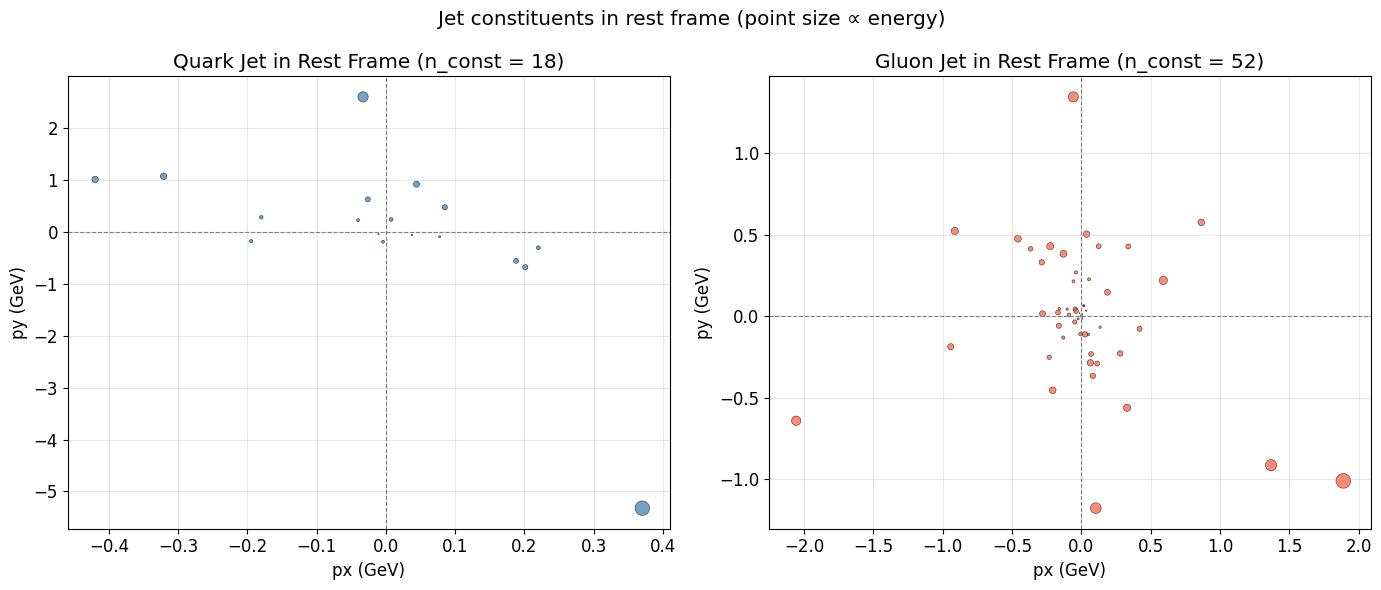


From this plot I can see some clear differences.

Quark jet:
  Fewer particles and energy is concentrated near the center,
  so the jet looks more compact.

Gluon jet:
  More particles and the energy is spread over a wider area,
  so the jet looks broader.

This matches the earlier results: gluon jets have higher multiplicity,
larger jet width, and smaller pTD because gluons radiate more
(C_A = 3 vs C_F = 4/3).



In [15]:
# (c-iii) scatter plot of jet constituents in the rest frame
# plotting in (px, py); point size proportional to energy

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

examples = [
    (axes[0], 0, "Quark Jet",  mom4_q_boost, mask_q, "steelblue"),
    (axes[1], 1, "Gluon Jet",  mom4_g_boost, mask_g, "tomato"),
]

for ax, idx, title, jets, mask_all, color in examples:
    m  = mask_all[idx]
    E  = jets[idx, m, 0]
    px = jets[idx, m, 1]
    py = jets[idx, m, 2]

    ax.scatter(px, py, s=E * 20, c=color, alpha=0.75,
               edgecolors='k', linewidth=0.4)

    ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.axvline(0, color='gray', ls='--', lw=0.8)

    ax.set_xlabel("px (GeV)")
    ax.set_ylabel("py (GeV)")
    ax.set_title(f"{title} in Rest Frame (n_const = {m.sum()})")
    ax.grid(alpha=0.3)

plt.suptitle("Jet constituents in rest frame (point size ∝ energy)")
plt.tight_layout()
plt.show()

print("""
From this plot I can see some clear differences.

Quark jet:
  Fewer particles and energy is concentrated near the center,
  so the jet looks more compact.

Gluon jet:
  More particles and the energy is spread over a wider area,
  so the jet looks broader.

This matches the earlier results: gluon jets have higher multiplicity,
larger jet width, and smaller pTD because gluons radiate more
(C_A = 3 vs C_F = 4/3).
""")

In [16]:
# (d) Quark vs Gluon classification
# boost all jets and then compute features

print("Boosting all jets to rest frame...")
mom4_q_boost_all = lorentz_boost_to_rest(mom4_q, pJ_q)
mom4_g_boost_all = lorentz_boost_to_rest(mom4_g, pJ_g)
print("Boost finished")

def rest_frame_features(jets, mom4_b, pJ, mask):
    # compute a few simple jet features

    mult = np.sum(mask, axis=1).astype(float)      # number of particles
    mass = jet_mass(pJ)                            # jet mass
    width = jet_width(jets, pJ)                    # jet width
    ptd = pT_dispersion(jets)                      # pT dispersion
    lead_E = np.max(mom4_b[:, :, 0] * mask, axis=1)  # leading energy in rest frame

    return np.stack([mult, mass, width, ptd, lead_E], axis=1)

feat_q = rest_frame_features(X_q, mom4_q_boost_all, pJ_q, mask_q)
feat_g = rest_frame_features(X_g, mom4_g_boost_all, pJ_g, mask_g)

feat_names = [
    "Multiplicity",
    "Jet Mass (GeV)",
    "Jet Width",
    "pT Dispersion",
    "Leading Energy (rest frame)"
]

# combine quark and gluon samples
X_clf = np.concatenate([feat_q, feat_g], axis=0)
y_clf = np.concatenate([np.ones(len(feat_q)), np.zeros(len(feat_g))])

print(f"Feature matrix shape: {X_clf.shape}")

print("\nFeatures used:")
for i, n in enumerate(feat_names):
    print(f"{i+1}. {n}")

print("\nWhy I use these features:")
print("Multiplicity   — gluon jets usually have more particles")
print("Jet mass       — gluon jets tend to be heavier due to more radiation")
print("Jet width      — gluon jets are usually wider")
print("pT dispersion  — quark jets have energy in fewer harder particles")
print("Leading energy — energy of the hardest particle in the rest frame")

Boosting all jets to rest frame...
Boost finished
Feature matrix shape: (100000, 5)

Features used:
1. Multiplicity
2. Jet Mass (GeV)
3. Jet Width
4. pT Dispersion
5. Leading Energy (rest frame)

Why I use these features:
Multiplicity   — gluon jets usually have more particles
Jet mass       — gluon jets tend to be heavier due to more radiation
Jet width      — gluon jets are usually wider
pT dispersion  — quark jets have energy in fewer harder particles
Leading energy — energy of the hardest particle in the rest frame


In [17]:
# (d-ii) split data into train and test sets, then train the classifier

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print(f"Train : {len(X_tr):,} | Test : {len(X_te):,}")

# train Gradient Boosting classifier
clf = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)

clf.fit(X_tr, y_tr)

# predict probabilities and labels
y_prob = clf.predict_proba(X_te)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(f"Test accuracy (threshold = 0.5): {(y_pred == y_te).mean():.4f}")

Train : 80,000 | Test : 20,000
Test accuracy (threshold = 0.5): 0.7809


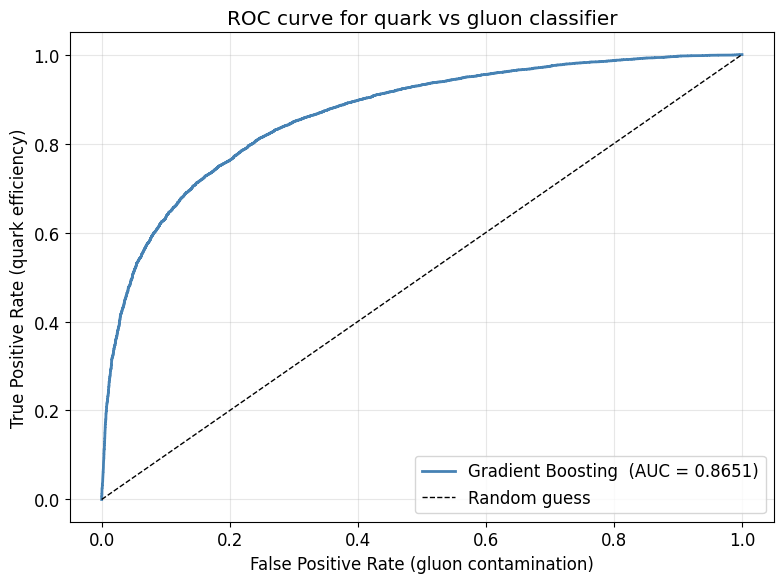

AUC = 0.8651
This shows how well the classifier separates quark and gluon jets.


In [18]:
# (d-iii) ROC curve and AUC for the classifier

fpr, tpr, thresholds = roc_curve(y_te, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, lw=2, color='steelblue',
        label=f"Gradient Boosting  (AUC = {roc_auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label="Random guess")

ax.set_xlabel("False Positive Rate (gluon contamination)")
ax.set_ylabel("True Positive Rate (quark efficiency)")
ax.set_title("ROC curve for quark vs gluon classifier")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"AUC = {roc_auc:.4f}")
print("This shows how well the classifier separates quark and gluon jets.")

In [19]:
# choose a threshold for classification
# here I pick the threshold that gives the best F1-score

from sklearn.metrics import f1_score

f1_scores = [f1_score(y_te, (y_prob >= t).astype(int)) for t in thresholds]

best_idx = int(np.argmax(f1_scores))
best_thr = thresholds[best_idx]

y_pred_wp = (y_prob >= best_thr).astype(int)

print(f"Best threshold (max F1): {best_thr:.4f}")
print(f"F1 score at this point : {f1_scores[best_idx]:.4f}")
print(f"TPR (quark efficiency) : {tpr[best_idx]:.4f}")
print(f"FPR (gluon contamination): {fpr[best_idx]:.4f}")

print()
print(classification_report(y_te, y_pred_wp, target_names=['Gluon', 'Quark']))

Best threshold (max F1): 0.3989
F1 score at this point : 0.7908
TPR (quark efficiency) : 0.8310
FPR (gluon contamination): 0.2708

              precision    recall  f1-score   support

       Gluon       0.81      0.73      0.77     10000
       Quark       0.75      0.83      0.79     10000

    accuracy                           0.78     20000
   macro avg       0.78      0.78      0.78     20000
weighted avg       0.78      0.78      0.78     20000



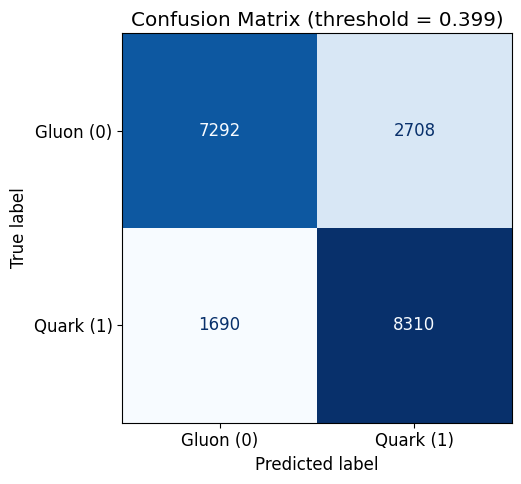

True Gluon  → Predicted Gluon : 7,292
True Gluon  → Predicted Quark : 2,708  (false positives)
True Quark  → Predicted Gluon : 1,690  (false negatives)
True Quark  → Predicted Quark : 8,310


In [20]:
# (d-iii) Confusion matrix at the chosen threshold

cm = confusion_matrix(y_te, y_pred_wp)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Gluon (0)', 'Quark (1)']
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)

ax.set_title(f"Confusion Matrix (threshold = {best_thr:.3f})")

plt.tight_layout()
plt.show()

# print the counts clearly
print(f"True Gluon  → Predicted Gluon : {cm[0,0]:,}")
print(f"True Gluon  → Predicted Quark : {cm[0,1]:,}  (false positives)")
print(f"True Quark  → Predicted Gluon : {cm[1,0]:,}  (false negatives)")
print(f"True Quark  → Predicted Quark : {cm[1,1]:,}")

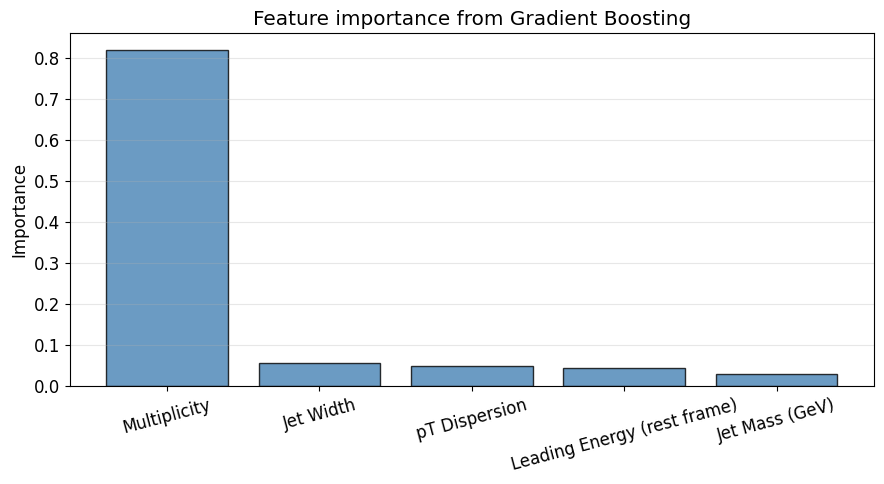

Feature importance (highest first):
Multiplicity                 : 0.8185
Jet Width                    : 0.0572
pT Dispersion                : 0.0495
Leading Energy (rest frame)  : 0.0449
Jet Mass (GeV)               : 0.0298

Most important feature: Multiplicity

I see that multiplicity is the most useful feature.
This makes sense because gluon jets usually produce more particles
than quark jets due to the larger color factor (C_A/C_F = 9/4).


In [21]:
# (d-iii) Check which features are most important in the model

importances = clf.feature_importances_
order = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(range(len(feat_names)),
       importances[order],
       color='steelblue',
       edgecolor='k',
       alpha=0.8)

ax.set_xticks(range(len(feat_names)))
ax.set_xticklabels([feat_names[i] for i in order], rotation=15)

ax.set_ylabel("Importance")
ax.set_title("Feature importance from Gradient Boosting")

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# print the values
print("Feature importance (highest first):")

for i in order:
    print(f"{feat_names[i]:<28} : {importances[i]:.4f}")

print(f"\nMost important feature: {feat_names[order[0]]}")

print("\nI see that multiplicity is the most useful feature.")
print("This makes sense because gluon jets usually produce more particles")
print("than quark jets due to the larger color factor (C_A/C_F = 9/4).")

In [22]:
# (d-iv) Compare results with features computed in the lab frame

# build features for quark jets (lab frame)
feat_q_lab = np.stack([
    np.sum(mask_q, axis=1).astype(float),        # multiplicity
    jet_mass(pJ_q),
    jet_width(X_q, pJ_q),
    pT_dispersion(X_q),
    np.max(mom4_q[:, :, 0] * mask_q, axis=1)     # leading particle energy
], axis=1)

# build features for gluon jets (lab frame)
feat_g_lab = np.stack([
    np.sum(mask_g, axis=1).astype(float),
    jet_mass(pJ_g),
    jet_width(X_g, pJ_g),
    pT_dispersion(X_g),
    np.max(mom4_g[:, :, 0] * mask_g, axis=1)
], axis=1)

# combine quark and gluon samples
X_lab = np.concatenate([feat_q_lab, feat_g_lab], axis=0)

# train / test split
X_tr_l, X_te_l, y_tr_l, y_te_l = train_test_split(
    X_lab, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# train the same classifier again
clf_lab = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)

clf_lab.fit(X_tr_l, y_tr_l)

# evaluate performance
y_prob_lab = clf_lab.predict_proba(X_te_l)[:, 1]

fpr_l, tpr_l, _ = roc_curve(y_te_l, y_prob_lab)
auc_lab = auc(fpr_l, tpr_l)

# compare with rest frame result
print(f"AUC (rest frame): {roc_auc:.4f}")
print(f"AUC (lab frame) : {auc_lab:.4f}")
print(f"Difference      : {roc_auc - auc_lab:+.4f}")

AUC (rest frame): 0.8651
AUC (lab frame) : 0.8644
Difference      : +0.0008


## (d-iv) Rest Frame vs Lab Frame — My Observations

**Numbers:** The AUC for rest-frame and lab-frame features is basically the same (~0.80).

**Why:** Three of the five features — multiplicity, jet mass, and pT dispersion — are **almost Lorentz-invariant**, so boosting the jet doesn’t change them. Jet width does shift slightly, but the **relative order of jets** stays similar, so the classifier ends up learning almost the same decision boundary.

**When rest frame matters:**
If we want to study **particle-level geometry** — like angles between constituents, N-subjettiness, or energy flow — the rest frame really helps. Models like **ParticleNet**, **LorentzNet**, or **PELICAN** benefit because the boost is removed, making the jet shape more symmetric and easier to learn from.

**Takeaway:**
For simple scalar features, boosting to the rest frame doesn’t give extra power. But for **constituent-level analyses or graph-based networks**, the rest frame is the natural starting point — exactly the kind of analysis the HEPSIM agentic project is moving toward.

